In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

df = pd.read_csv('churn-bigml-80.csv')

df['International plan'] = df['International plan'].map({'Yes':1, 'No':0})
df['Voice mail plan'] = df['Voice mail plan'].map({'Yes':1, 'No':0})
df['Churn'] = df['Churn'].astype(int)

print("Shape:", df.shape)
df.head()

Shape: (2666, 20)


,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,KS,128,415,0,1,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,0
1,OH,107,415,0,1,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,0
2,NJ,137,415,0,0,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,0
3,OH,84,408,1,0,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,0
4,OK,75,415,1,0,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,0


Training the Linear Regression Model

In [5]:
# Linear Regression Model
# Defining the features of the target varible
x = df[['Total day minutes']]
y = df['Total day charge']
# spliting into 80% training and 20% testing data
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.20, random_state=42)
# Fitting the regression model
model = LinearRegression()
model.fit(x_train, y_train)
#Making predictions
y_pred = model.predict(x_test)
slope = model.coef_[0]
intercept = model.intercept_
print(f"Model Training Complete!")
print(f"Regression Equation: Total day charge = ({slope:.4f} * Total day minutes) + ({intercept:.4f})")

Model Training Complete!
Regression Equation: Total day charge = (0.1700 * Total day minutes) + (0.0006)


Plot the Regression Line

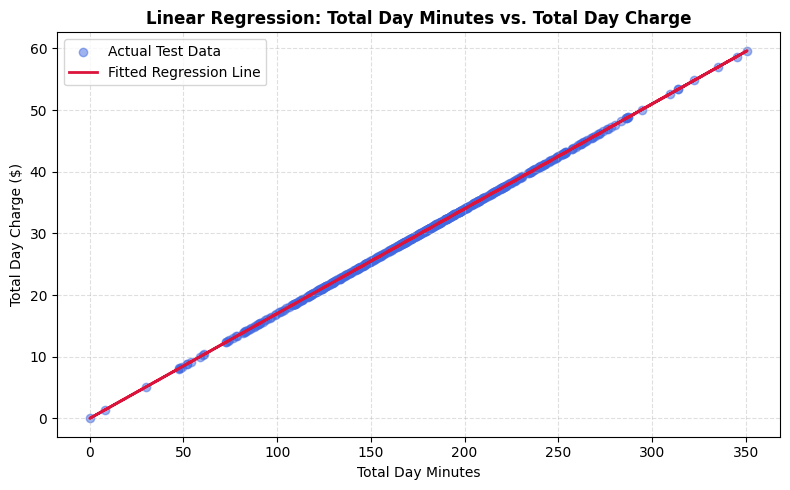

In [7]:
# Visualizing the Best Fit Line
plt.figure(figsize=(8, 5))
plt.scatter(x_test, y_test, color='royalblue', alpha=0.5, label='Actual Test Data')
plt.plot(x_test, y_pred, color='crimson', linewidth=2, label='Fitted Regression Line')
plt.title('Linear Regression: Total Day Minutes vs. Total Day Charge', fontweight='bold')
plt.xlabel('Total Day Minutes')
plt.ylabel('Total Day Charge ($)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

Feature Scaling & Elbow Method

By selecting the customer usage behaviors (Total day minutes, Total eve minutes, Total night minutes, Customer service calls) and scaling them.

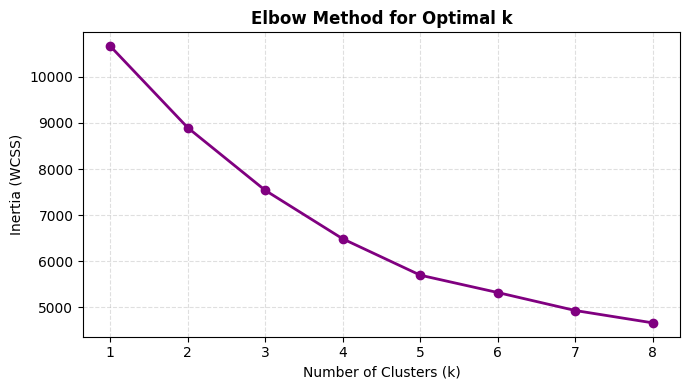

In [14]:
# Feature Scaling & Optimal Clusters (Elbow Method)
cluster_features = ['Total day minutes', 'Total eve minutes', 'Total night minutes', 'Customer service calls']
X_cluster = df[cluster_features]

# Scaling features so minutes and call counts carry equal mathematical weight
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

# Calculate inertia for k = 1 to 8
inertia = []
K_range = range(1, 9)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Plot the Elbow Curve
xlab = 'Number of Clusters (k)'
ylab = 'Inertia (WCSS)'
plt.figure(figsize=(7, 4))
plt.plot(K_range, inertia, marker='o', color='purple', linewidth=2)
plt.title('Elbow Method for Optimal k', fontweight='bold')
plt.xlabel(xlab)
plt.ylabel(ylab)
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

In [9]:
# Fit K-Means with k=3 & Profile Customer Segments
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

# View the average usage across the 3 clusters
cluster_profile = df.groupby('Cluster')[cluster_features + ['Churn']].mean().round(2)
print("Customer Personas Summary:")
cluster_profile

Customer Personas Summary:


,Total day minutes,Total eve minutes,Total night minutes,Customer service calls,Churn
Cluster,,,,,
0,191.12,181.22,237.82,1.05,0.13
1,182.55,195.75,196.50,3.52,0.27
2,165.87,222.57,166.11,1.03,0.10


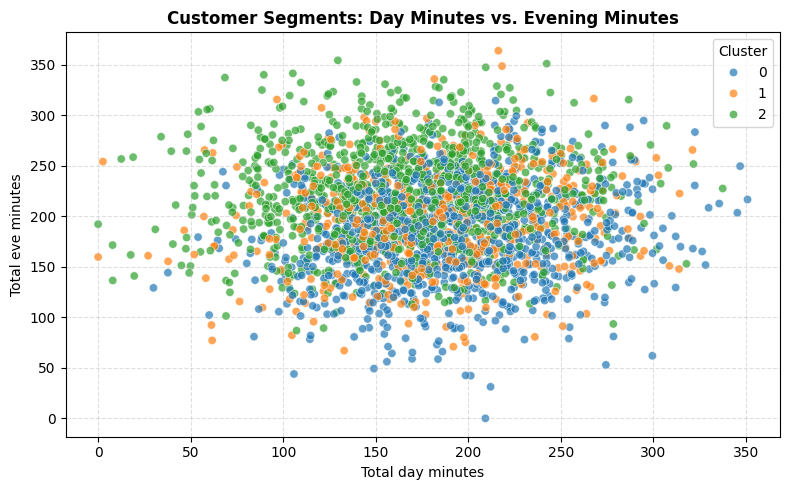

In [12]:
# Scatter Plot of Customer Segments
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df,
    x='Total day minutes',
    y='Total eve minutes',
    hue='Cluster',
    palette='tab10',
    alpha=0.7
)
plt.title('Customer Segments: Day Minutes vs. Evening Minutes', fontweight='bold')
plt.xlabel('Total day minutes')
plt.ylabel('Total eve minutes')
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()